## Cell 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
MODEL_DIR  = '/content/drive/MyDrive/insurance_fraud/models/'
REPORT_DIR = '/content/drive/MyDrive/insurance_fraud/reports/'
SCAN_DIR   = '/content/drive/MyDrive/insurance_fraud/scanned/'
os.makedirs(SCAN_DIR, exist_ok=True)
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Cell 2 — Install Dependencies

In [ ]:
# Core OCR and document processing
!pip install easyocr pdf2image pillow reportlab gradio xgboost --quiet
!apt-get install -y poppler-utils --quiet  # Required by pdf2image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import joblib
import re
import io
import warnings
import shap
from datetime import datetime
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import easyocr
import gradio as gr
warnings.filterwarnings('ignore')

# ReportLab for PDF output
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table,
    TableStyle, HRFlowable, Image as RLImage
)
from reportlab.lib.enums import TA_CENTER, TA_LEFT

# Colors
NAVY='#0D1B3E'; CARD='#132447'; ACCENT='#1DB8C4'
GREEN='#22C97A'; RED='#E84C4C'; YELLOW='#F5C842'
WHITE='#FFFFFF'; GRAY='#8BA3BF'

print('✅ All packages installed and imported.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 20.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (656 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack ...

## Cell 3 — Load Trained Models

In [ ]:
# Load XGBoost model from M4
xgb_model = joblib.load(MODEL_DIR + 'model_xgboost.pkl')
scaler    = joblib.load(MODEL_DIR + 'scaler.pkl')

# Load feature list from M3
with open(OUTPUT_DIR + 'final_feature_columns.json') as f:
    feature_cols = json.load(f)

# Load model metadata
with open(MODEL_DIR + 'model_metadata.json') as f:
    metadata = json.load(f)

# Load population means for comparison (from val set)
X_val = pd.read_parquet(MODEL_DIR + 'X_val.parquet')
X_val = X_val[[c for c in feature_cols if c in X_val.columns]]
pop_means = X_val.mean().to_dict()
pop_stds  = X_val.std().to_dict()

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

THRESHOLD = metadata['best_threshold']

print(f'✅ Models loaded:')
print(f'   XGBoost (M4)       : loaded')
print(f'   Feature columns    : {len(feature_cols)}')
print(f'   Decision threshold : {THRESHOLD}')
print(f'   Model AUC-ROC      : {metadata["val_auc_roc"]}')

✅ Models loaded:
   XGBoost (M4)       : loaded
   Feature columns    : 74
   Decision threshold : 0.73
   Model AUC-ROC      : 0.9704


## Cell 4 — Initialize EasyOCR

In [ ]:
# Initialize EasyOCR — downloads model on first run (~200MB, takes ~1-2 min)
print('🔄 Initializing EasyOCR (downloads model on first run)...')
reader = easyocr.Reader(['en'], gpu=True)
print('✅ EasyOCR ready (GPU mode).')

🔄 Initializing EasyOCR (downloads model on first run)...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ EasyOCR ready (GPU mode).


## Cell 5 — OCR Engine: Extract Text + Bounding Boxes

In [ ]:
def ocr_document(file_path):
    """
    Accepts PDF or image file.
    Returns:
      - raw_text: full extracted text string
      - ocr_results: list of (bbox, text, confidence)
      - pil_image: PIL image of the first page
    """
    file_path = str(file_path)
    ext = Path(file_path).suffix.lower()

    # Convert PDF to image first
    if ext == '.pdf':
        from pdf2image import convert_from_path
        pages = convert_from_path(file_path, dpi=200)
        pil_image = pages[0]  # Scan first page
        print(f'  PDF → converted page 1 of {len(pages)}')
    elif ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
        pil_image = Image.open(file_path).convert('RGB')
    else:
        raise ValueError(f'Unsupported file type: {ext}. Use PDF, JPG, or PNG.')

    # Run EasyOCR
    print(f'  Running OCR on {pil_image.size[0]}×{pil_image.size[1]} image...')
    ocr_results = reader.readtext(np.array(pil_image))

    # Format: [(bbox, text, confidence), ...]
    raw_text = ' '.join([r[1] for r in ocr_results])

    print(f'  ✅ Extracted {len(ocr_results)} text regions')
    print(f'  ✅ Raw text length: {len(raw_text)} chars')

    return raw_text, ocr_results, pil_image


print('✅ ocr_document() defined.')

✅ ocr_document() defined.


## Cell 6 — Field Parser: Map OCR Text → Structured Claim Fields

In [ ]:
# Regex patterns for common insurance claim fields
FIELD_PATTERNS = {
    # Claim amounts — $ or INR formats
    'claim_amount': [
        r'(?:claim\s*amount|total\s*claim|amount\s*claimed)[\s:]*[\$₹Rs\.]*([\d,]+(?:\.\d{1,2})?)',
        r'[\$₹]\s*([\d,]{3,}(?:\.\d{1,2})?)',
        r'([\d,]{4,})(?:\s*(?:USD|INR|Rs))',
    ],
    # Reimbursement amount
    'reimbursement_amount': [
        r'(?:reimburs|reimb)[\w\s]*[:\s]*[\$₹Rs\.]*([\d,]+(?:\.\d{1,2})?)',
        r'(?:approved|paid|settled)[\s:]*[\$₹Rs\.]*([\d,]+(?:\.\d{1,2})?)',
    ],
    # Doctor / Physician ID
    'doctor_id': [
        r'(?:physician|doctor|dr\.?|attending)[\s:]*(?:id|code|no\.?)?[\s:]*([A-Z]{2,4}\d{4,})',
        r'(?:npi|provider\s*id)[\s:]*([\d]{10})',
        r'DR\.?\s*([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)',
    ],
    # Patient / Beneficiary ID
    'patient_id': [
        r'(?:patient|beneficiary|member)\s*(?:id|no\.?|#)[\s:]*([A-Z0-9]{6,})',
        r'(?:BeneID|PatID)[\s:]*([A-Z0-9]+)',
    ],
    # Hospital / Provider name
    'provider_name': [
        r'(?:hospital|clinic|medical\s*center|provider)[\s:]*([A-Z][\w\s]+(?:Hospital|Clinic|Medical|Health|Care))',
        r'([A-Z][\w\s]+(?:Hospital|Clinic|Medical\s*Center))',
    ],
    # Admission date
    'admission_date': [
        r'(?:admit|admission|admitted)[\s:]*(?:date|dt)?[\s:]*([\d]{1,2}[/-][\d]{1,2}[/-][\d]{2,4})',
        r'(?:from|start)[\s:]*([\d]{1,2}[/-][\d]{1,2}[/-][\d]{2,4})',
    ],
    # Discharge date
    'discharge_date': [
        r'(?:discharge|discharged|to)[\s:]*(?:date|dt)?[\s:]*([\d]{1,2}[/-][\d]{1,2}[/-][\d]{2,4})',
    ],
    # Claim date
    'claim_date': [
        r'(?:claim\s*date|date\s*of\s*claim|filed)[\s:]*([\d]{1,2}[/-][\d]{1,2}[/-][\d]{2,4})',
        r'(?:date)[\s:]*([\d]{1,2}[/-][\d]{1,2}[/-][\d]{2,4})',
    ],
    # Diagnosis codes (ICD-10)
    'diagnosis_code': [
        r'(?:icd|diagnosis\s*code|diag)[\s:]*([A-Z]\d{2}\.?\d{0,2})',
        r'([A-Z]\d{2}\.\d{1,2})(?:\s|,)',
    ],
    # Deductible amount
    'deductible_amount': [
        r'(?:deductible|deduct)[\s:]*[\$₹Rs\.]*([\d,]+(?:\.\d{1,2})?)',
    ],
    # Number of days
    'hospital_days': [
        r'([\d]+)\s*(?:days?|nights?)\s*(?:of\s*)?(?:stay|admission|hospitalization)',
        r'(?:stay|duration)[\s:]*([\d]+)\s*days?',
    ],
    # Patient age
    'patient_age': [
        r'(?:age|aged?)[\s:]*([\d]{1,3})\s*(?:years?|yrs?)?',
        r'([\d]{2,3})\s*(?:year|yr)\s*(?:old|male|female)',
    ],
    # Number of diagnoses
    'num_diagnoses': [
        r'(?:diagnos[ei][sd])[\s:]*([\d]+)',
        r'([\d]+)\s*(?:diagnos|conditions?|chronic)',
    ],
}


def parse_claim_fields(raw_text):
    """
    Extracts structured fields from raw OCR text using regex patterns.
    Returns a dict of field_name → extracted_value.
    """
    extracted = {}
    text_upper = raw_text.upper()

    for field, patterns in FIELD_PATTERNS.items():
        for pattern in patterns:
            match = re.search(pattern, raw_text, re.IGNORECASE)
            if match:
                raw_val = match.group(1).strip()
                # Clean numeric fields
                if field in ['claim_amount','reimbursement_amount',
                              'deductible_amount','hospital_days','patient_age','num_diagnoses']:
                    clean = re.sub(r'[,\s]', '', raw_val)
                    try:
                        extracted[field] = float(clean)
                    except:
                        extracted[field] = raw_val
                else:
                    extracted[field] = raw_val
                break  # Use first matching pattern

    # Compute stay duration if we have both dates
    if 'admission_date' in extracted and 'discharge_date' in extracted:
        try:
            from dateutil import parser as dparser
            admit   = dparser.parse(str(extracted['admission_date']), dayfirst=True)
            disch   = dparser.parse(str(extracted['discharge_date']), dayfirst=True)
            days    = max(0, (disch - admit).days)
            extracted['hospital_days'] = float(days)
        except:
            pass

    return extracted


print('✅ Field parser defined with', len(FIELD_PATTERNS), 'field patterns.')

✅ Field parser defined with 13 field patterns.


## Cell 7 — Feature Builder: Extracted Fields → Model Features

In [ ]:
def build_features_from_claim(fields):
    """
    Converts extracted claim fields into the feature vector the XGBoost
    model expects. Missing fields default to population means.
    Returns a DataFrame with all feature_cols.
    """
    feat = {}

    # ── Fill all features with population mean as default ──────────────────────
    for col in feature_cols:
        feat[col] = pop_means.get(col, 0.0)

    # ── Map extracted fields to model features ──────────────────────────────────
    # Claim amount → reimbursement feature
    if 'claim_amount' in fields and isinstance(fields['claim_amount'], float):
        amt = fields['claim_amount']
        if 'ip_avg_reimbursement'   in feat: feat['ip_avg_reimbursement']   = amt
        if 'ip_total_reimbursement' in feat: feat['ip_total_reimbursement'] = amt
        if 'op_avg_reimbursement'   in feat: feat['op_avg_reimbursement']   = amt * 0.3

    if 'reimbursement_amount' in fields and isinstance(fields['reimbursement_amount'], float):
        reimb = fields['reimbursement_amount']
        if 'ip_avg_reimbursement'   in feat: feat['ip_avg_reimbursement']   = reimb
        if 'ip_total_reimbursement' in feat: feat['ip_total_reimbursement'] = reimb

    # Hospital stay days
    if 'hospital_days' in fields and isinstance(fields['hospital_days'], float):
        days = min(fields['hospital_days'], 365)
        if 'ip_avg_stay_days'   in feat: feat['ip_avg_stay_days']   = days
        if 'ip_max_stay_days'   in feat: feat['ip_max_stay_days']   = days
        if 'ip_total_stay_days' in feat: feat['ip_total_stay_days'] = days

    # Patient age
    if 'patient_age' in fields and isinstance(fields['patient_age'], float):
        age = min(fields['patient_age'], 120)
        if 'ip_avg_patient_age' in feat: feat['ip_avg_patient_age'] = age
        if 'op_avg_patient_age' in feat: feat['op_avg_patient_age'] = age

    # Number of diagnoses → chronic condition score
    if 'num_diagnoses' in fields and isinstance(fields['num_diagnoses'], float):
        n_diag = fields['num_diagnoses']
        if 'ip_avg_chronic_cond' in feat: feat['ip_avg_chronic_cond'] = min(n_diag, 11)
        if 'ip_max_chronic_cond' in feat: feat['ip_max_chronic_cond'] = min(n_diag, 11)

    # Deductible
    if 'deductible_amount' in fields and isinstance(fields['deductible_amount'], float):
        ded = fields['deductible_amount']
        if 'ip_total_deductible' in feat: feat['ip_total_deductible'] = ded
        if 'ip_avg_deductible'   in feat: feat['ip_avg_deductible']   = ded

    # ── Recompute derived features with extracted values ────────────────────────
    eps = 1e-9
    reimb  = feat.get('ip_avg_reimbursement', 0)
    claims = feat.get('ip_claim_count', 1)
    pats   = feat.get('ip_unique_patients', 1)
    ded    = feat.get('ip_total_deductible', 1)

    if 'feat_reimb_per_ip_claim'       in feat: feat['feat_reimb_per_ip_claim']       = reimb / (claims + eps)
    if 'feat_reimb_per_unique_patient' in feat: feat['feat_reimb_per_unique_patient'] = reimb / (pats + eps)
    if 'feat_deductible_ratio'         in feat: feat['feat_deductible_ratio']         = ded   / (reimb + eps)
    if 'feat_stay_days_per_claim'      in feat:
        feat['feat_stay_days_per_claim'] = feat.get('ip_avg_stay_days', 0) / (claims + eps)

    # Recompute risk scores
    if 'risk_financial' in feat:
        reimb_pct = min(reimb / max(pop_means.get('ip_avg_reimbursement', 1), eps), 3) / 3
        feat['risk_financial'] = reimb_pct

    if 'risk_stay_duration' in feat:
        stay_days = feat.get('ip_avg_stay_days', 0)
        stay_pct  = min(stay_days / max(pop_means.get('ip_avg_stay_days', 1) * 3, eps), 1)
        feat['risk_stay_duration'] = stay_pct

    if 'risk_composite_score' in feat:
        feat['risk_composite_score'] = np.mean([
            feat.get('risk_financial', 0.5),
            feat.get('risk_volume', 0.5),
            feat.get('risk_medical_complexity', 0.5),
            feat.get('risk_stay_duration', 0.5),
        ])

    # Z-score features
    for col in feature_cols:
        if col.startswith('zscore_'):
            base = col.replace('zscore_', '')
            if base in feat:
                mean = pop_means.get(base, 0)
                std  = max(pop_stds.get(base, 1), eps)
                feat[col] = (feat[base] - mean) / std

    # Interaction features
    if 'interact_volume_x_reimb' in feat:
        feat['interact_volume_x_reimb'] = (
            np.log1p(feat.get('ip_claim_count', 0)) *
            np.log1p(feat.get('ip_avg_reimbursement', 0))
        )
    if 'interact_stay_x_reimb' in feat:
        feat['interact_stay_x_reimb'] = (
            feat.get('ip_avg_stay_days', 0) *
            np.log1p(feat.get('ip_avg_reimbursement', 0))
        )
    if 'interact_composite_squared' in feat:
        feat['interact_composite_squared'] = feat.get('risk_composite_score', 0.5) ** 2

    # Build DataFrame — all features in correct order
    feat_df = pd.DataFrame([feat])[feature_cols]
    feat_df = feat_df.fillna(0).replace([np.inf, -np.inf], 0)
    return feat_df


print('✅ Feature builder defined.')

✅ Feature builder defined.


## Cell 8 — Per-Field Suspicion Scorer

In [ ]:
def score_fields(fields, feat_df):
    """
    Computes a suspicion score (0-1) for each extracted claim field.
    Returns dict: field_name → {value, suspicion_score, reason}
    """
    field_scores = {}
    eps = 1e-9

    FIELD_RULES = {
        'claim_amount': {
            'feature'  : 'ip_avg_reimbursement',
            'threshold': lambda v, avg: v > avg * 2.5,
            'reason'   : lambda v, avg: f'Claim amount ${v:,.0f} is {v/max(avg,eps):.1f}x population average (${avg:,.0f})'
        },
        'reimbursement_amount': {
            'feature'  : 'ip_avg_reimbursement',
            'threshold': lambda v, avg: v > avg * 2.0,
            'reason'   : lambda v, avg: f'Reimbursement ${v:,.0f} is {v/max(avg,eps):.1f}x above average'
        },
        'hospital_days': {
            'feature'  : 'ip_avg_stay_days',
            'threshold': lambda v, avg: v > avg * 2.0,
            'reason'   : lambda v, avg: f'Hospital stay of {v:.0f} days is {v/max(avg,eps):.1f}x the typical {avg:.1f} days'
        },
        'num_diagnoses': {
            'feature'  : 'ip_avg_chronic_cond',
            'threshold': lambda v, avg: v > 6,
            'reason'   : lambda v, avg: f'{v:.0f} diagnoses billed — high count suggests diagnosis stuffing'
        },
        'patient_age': {
            'feature'  : 'ip_avg_patient_age',
            'threshold': lambda v, avg: v > 90 or v < 1,
            'reason'   : lambda v, avg: f'Patient age {v:.0f} is unusual — verify records'
        },
        'deductible_amount': {
            'feature'  : 'ip_avg_deductible',
            'threshold': lambda v, avg: avg > 0 and v < avg * 0.1,
            'reason'   : lambda v, avg: f'Deductible ${v:,.0f} is very low vs claim amount — possible system gaming'
        },
        'diagnosis_code': {
            'feature'  : None,
            'threshold': lambda v, avg: False,  # ICD code — flag for manual review
            'reason'   : lambda v, avg: f'ICD code {v} — verify matches claim type and patient condition'
        },
    }

    for field, value in fields.items():
        rule = FIELD_RULES.get(field)
        if rule is None:
            field_scores[field] = {
                'value'           : value,
                'suspicion_score' : 0.0,
                'suspicious'      : False,
                'reason'          : 'No rule defined — manual review recommended'
            }
            continue

        feat_name = rule['feature']
        avg = pop_means.get(feat_name, 0) if feat_name else 0
        std = pop_stds.get(feat_name, 1)  if feat_name else 1

        try:
            numeric_val = float(value) if not isinstance(value, float) else value
        except:
            numeric_val = 0

        # Suspicion score = how many std devs above mean
        if feat_name and std > 0:
            z = (numeric_val - avg) / std
            score = min(max(z / 4, 0), 1)  # Normalise: z=4 → score=1
        else:
            score = 0.0

        is_suspicious = rule['threshold'](numeric_val, avg)
        if is_suspicious:
            score = max(score, 0.7)  # At least 0.7 if rule fires

        field_scores[field] = {
            'value'           : value,
            'suspicion_score' : round(score, 3),
            'suspicious'      : is_suspicious or score > 0.5,
            'reason'          : rule['reason'](numeric_val, avg)
        }

    return field_scores


print('✅ Per-field scorer defined.')

✅ Per-field scorer defined.


## Cell 9 — Document Highlighter: Mark Suspicious Fields on Image

In [ ]:
def highlight_document(pil_image, ocr_results, field_scores, output_path=None):
    """
    Overlays color-coded bounding boxes on the document image:
    - Red box    = suspicious field (score > 0.5)
    - Yellow box = moderate concern (score > 0.25)
    - Green box  = normal
    Returns annotated PIL image.
    """
    img = pil_image.copy().convert('RGBA')
    overlay = Image.new('RGBA', img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    suspicious_keywords = set()
    for field, info in field_scores.items():
        if info['suspicious']:
            val = str(info['value']).lower()
            suspicious_keywords.update(val.split())

    for (bbox, text, conf) in ocr_results:
        # bbox is [[x1,y1],[x2,y1],[x2,y2],[x1,y2]]
        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]
        x1, y1 = int(min(xs)), int(min(ys))
        x2, y2 = int(max(xs)), int(max(ys))

        text_lower = text.lower()
        matched_field = None
        max_score = 0

        # Match OCR text region to a field score
        for field, info in field_scores.items():
            val_str = str(info['value']).lower()
            # Check if this text region contains the extracted value
            if (val_str[:8] in text_lower or
                any(kw in text_lower for kw in val_str.split() if len(kw) > 3)):
                if info['suspicion_score'] > max_score:
                    max_score    = info['suspicion_score']
                    matched_field = field

        # Color based on suspicion
        if matched_field and max_score > 0.5:
            box_color  = (232, 76, 76, 100)   # Red (transparent)
            line_color = (232, 76, 76, 220)
        elif matched_field and max_score > 0.25:
            box_color  = (245, 200, 66, 80)
            line_color = (245, 200, 66, 200)
        elif conf > 0.7:
            box_color  = (34, 201, 122, 30)
            line_color = (34, 201, 122, 120)
        else:
            continue

        draw.rectangle([x1-2, y1-2, x2+2, y2+2], fill=box_color, outline=line_color, width=2)

    # Merge overlay
    annotated = Image.alpha_composite(img, overlay).convert('RGB')

    # Legend
    legend_h = 45
    legend = Image.new('RGB', (annotated.width, legend_h), (13, 27, 62))
    legend_draw = ImageDraw.Draw(legend)
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 14)
    except:
        font = ImageFont.load_default()
    legend_draw.rectangle([10, 10, 28, 35], fill=(232, 76, 76))
    legend_draw.text((34, 12), 'Suspicious field', fill=(255,255,255), font=font)
    legend_draw.rectangle([200, 10, 218, 35], fill=(245, 200, 66))
    legend_draw.text((224, 12), 'Moderate concern', fill=(255,255,255), font=font)
    legend_draw.rectangle([400, 10, 418, 35], fill=(34, 201, 122))
    legend_draw.text((424, 12), 'Normal', fill=(255,255,255), font=font)

    final = Image.new('RGB', (annotated.width, annotated.height + legend_h))
    final.paste(annotated, (0, 0))
    final.paste(legend, (0, annotated.height))

    if output_path:
        final.save(output_path)
        print(f'  💾 Highlighted image saved: {output_path}')

    return final


print('✅ Document highlighter defined.')

✅ Document highlighter defined.


## Cell 10 — Full Document Scan Pipeline

In [ ]:
def scan_document(file_path, save_outputs=True):
    """
    Full end-to-end document fraud scan pipeline.
    Input : file_path (PDF or image)
    Output: dict with fraud_score, field_scores, annotated image,
            natural language reasons, risk tier
    """
    print(f'\n🔍 Scanning: {file_path}')
    print('─'*55)
    results = {}

    # Step 1: OCR
    print('Step 1/5 — OCR extraction...')
    raw_text, ocr_results, pil_image = ocr_document(file_path)
    results['raw_text']    = raw_text
    results['ocr_regions'] = len(ocr_results)

    # Step 2: Field parsing
    print('Step 2/5 — Field parsing...')
    fields = parse_claim_fields(raw_text)
    results['extracted_fields'] = fields
    print(f'  Extracted {len(fields)} fields: {list(fields.keys())}')

    # Step 3: Feature building
    print('Step 3/5 — Building model features...')
    feat_df = build_features_from_claim(fields)

    # Step 4: Fraud prediction
    print('Step 4/5 — Fraud prediction...')
    fraud_proba = xgb_model.predict_proba(feat_df)[0, 1]
    fraud_pred  = int(fraud_proba >= THRESHOLD)

    # SHAP explanation
    shap_vals = explainer(feat_df)
    shap_series = pd.Series(
        shap_vals.values[0],
        index=feature_cols
    ).sort_values(ascending=False)

    # Top fraud drivers from SHAP
    top_shap = shap_series[shap_series > 0].head(5)

    # Natural language reasons
    reasons = []
    TEMPLATES = {
        'ip_avg_reimbursement'     : 'Claim amount is {ratio:.1f}x the population average',
        'ip_avg_stay_days'         : 'Hospital stay is {ratio:.1f}x longer than typical',
        'ip_avg_chronic_cond'      : 'Number of diagnoses ({val:.0f}) is unusually high',
        'risk_financial'           : 'Financial risk score {val:.3f} — in high-risk tier',
        'risk_composite_score'     : 'Overall composite risk score: {val:.3f}',
        'feat_reimb_per_ip_claim'  : 'Reimbursement per claim is {ratio:.1f}x average',
        'feat_deductible_ratio'    : 'Deductible ratio {val:.3f} — very low relative to claim',
        'interact_stay_x_reimb'    : 'Long stay combined with high claim — overbilling signal',
        'interact_volume_x_reimb'  : 'High claim value amplified by volume pattern',
    }
    for feat_name, shap_val in top_shap.items():
        val = float(feat_df[feat_name].iloc[0])
        avg = pop_means.get(feat_name, 0)
        ratio = val / max(avg, 1e-9)
        tmpl = TEMPLATES.get(feat_name,
            f'{feat_name.replace("_"," ").title()}: value={{val:.3f}} ({{ratio:.1f}}x avg)')
        try:
            reasons.append({
                'feature'    : feat_name,
                'shap'       : round(float(shap_val), 4),
                'reason_text': tmpl.format(val=val, avg=avg, ratio=ratio)
            })
        except:
            reasons.append({'feature': feat_name, 'shap': round(float(shap_val),4),
                            'reason_text': feat_name})

    # Risk tier
    if fraud_proba >= 0.85:
        tier, action = 'CRITICAL', 'Immediate investigation required — do not process'
    elif fraud_proba >= THRESHOLD:
        tier, action = 'HIGH',     'Flag for detailed manual review before approval'
    elif fraud_proba >= THRESHOLD * 0.7:
        tier, action = 'MEDIUM',   'Process with additional verification steps'
    else:
        tier, action = 'LOW',      'Approve — within normal parameters'

    results.update({
        'fraud_score'  : round(fraud_proba, 4),
        'fraud_pred'   : fraud_pred,
        'risk_tier'    : tier,
        'action'       : action,
        'reasons'      : reasons,
        'feat_df'      : feat_df,
    })

    # Step 5: Field scoring + highlighting
    print('Step 5/5 — Highlighting document...')
    field_scores = score_fields(fields, feat_df)
    results['field_scores'] = field_scores

    img_path = None
    if save_outputs:
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        img_path = SCAN_DIR + f'scan_highlighted_{ts}.png'
        annotated = highlight_document(pil_image, ocr_results,
                                       field_scores, img_path)
    else:
        annotated = highlight_document(pil_image, ocr_results, field_scores)

    results['annotated_image'] = annotated
    results['image_path']      = img_path

    # Print summary
    print('\n' + '='*55)
    print(f'  SCAN RESULT')
    print('='*55)
    print(f'  Fraud Score : {fraud_proba:.4f}')
    print(f'  Decision    : {"🚨 FRAUD" if fraud_pred else "✅ LEGITIMATE"}')
    print(f'  Risk Tier   : {tier}')
    print(f'  Action      : {action}')
    print(f'  Fields found: {len(fields)}')
    print(f'\n  Top Fraud Signals:')
    for i, r in enumerate(reasons[:5], 1):
        print(f'    {i}. {r["reason_text"]}  [SHAP: +{r["shap"]:.4f}]')
    print(f'\n  Suspicious fields:')
    for field, info in field_scores.items():
        if info['suspicious']:
            print(f'    ⚠️  {field}: {info["value"]} — {info["reason"]}')
    print('='*55)

    return results


print('✅ scan_document() pipeline defined.')

✅ scan_document() pipeline defined.


## Cell 11 — Test with a Synthetic Claim Document
> If you don't have a real claim PDF yet, this cell creates a synthetic one to test the full pipeline

In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import cm

def create_synthetic_claim_pdf(output_path, scenario='high_fraud'):
    """
    Creates a realistic-looking insurance claim PDF for testing.
    scenario='high_fraud' → suspicious values to trigger detection
    scenario='normal'     → typical legitimate values
    """
    if scenario == 'high_fraud':
        claim_data = {
            'Provider Name'       : 'MediCare Plus Hospital & Diagnostics',
            'Provider ID'         : 'PRV-994821',
            'Patient Name'        : 'John Michael Doe',
            'Patient ID'          : 'BNF-772341',
            'Patient Age'         : '78',
            'Admission Date'      : '01/03/2009',
            'Discharge Date'      : '01/05/2009',   # 61 days — very long
            'Attending Physician' : 'PHY-441928',
            'Claim Amount'        : '$124,500',      # Very high
            'Reimbursement Amount': '$118,750',
            'Deductible Amount'   : '$250',          # Very low deductible
            'Claim Date'          : '05/05/2009',
            'Diagnosis Code'      : 'I25.1, E11.9, N18.3, J44.1, M81.0, K74.6',  # 6 diagnoses
            'Num Diagnoses'       : '6',
            'Procedure Code'      : 'CPT-99215, CPT-71046, CPT-93000',
            'Claim Type'          : 'Inpatient',
            'Policy Number'       : 'POL-2009-88841',
        }
    else:  # Normal
        claim_data = {
            'Provider Name'       : 'City General Hospital',
            'Provider ID'         : 'PRV-112233',
            'Patient Name'        : 'Jane Smith',
            'Patient ID'          : 'BNF-441122',
            'Patient Age'         : '58',
            'Admission Date'      : '15/06/2009',
            'Discharge Date'      : '18/06/2009',   # 3 days — normal
            'Attending Physician' : 'PHY-221144',
            'Claim Amount'        : '$8,200',
            'Reimbursement Amount': '$7,400',
            'Deductible Amount'   : '$1,200',
            'Claim Date'          : '20/06/2009',
            'Diagnosis Code'      : 'I10',
            'Num Diagnoses'       : '1',
            'Procedure Code'      : 'CPT-99213',
            'Claim Type'          : 'Inpatient',
            'Policy Number'       : 'POL-2009-22231',
        }

    doc    = SimpleDocTemplate(output_path, pagesize=A4,
                               leftMargin=2*cm, rightMargin=2*cm,
                               topMargin=2*cm, bottomMargin=2*cm)
    styles = getSampleStyleSheet()
    story  = []

    title_s = styles['Title']; title_s.textColor = colors.HexColor('#1A3A6B')
    story.append(Paragraph('INSURANCE CLAIM FORM', title_s))
    story.append(Paragraph('Medicare/Medicaid Claim Submission', styles['Normal']))
    story.append(Spacer(1, 0.5*cm))

    table_data = [['Field', 'Value']] + [[k, v] for k, v in claim_data.items()]
    tbl = Table(table_data, colWidths=[8*cm, 9*cm])
    tbl.setStyle(TableStyle([
        ('BACKGROUND',   (0,0), (-1,0), colors.HexColor('#1A3A6B')),
        ('TEXTCOLOR',    (0,0), (-1,0), colors.white),
        ('FONTNAME',     (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE',     (0,0), (-1,-1), 11),
        ('ROWBACKGROUNDS',(0,1), (-1,-1),
         [colors.HexColor('#F0F4FF'), colors.white]),
        ('GRID',         (0,0), (-1,-1), 0.5, colors.grey),
        ('PADDING',      (0,0), (-1,-1), 8),
    ]))
    story.append(tbl)
    story.append(Spacer(1, 1*cm))
    story.append(Paragraph(
        'I certify that the information provided above is true and accurate '
        'to the best of my knowledge.',
        styles['Normal']
    ))
    doc.build(story)
    print(f'✅ Synthetic claim PDF created: {output_path}')
    return output_path


# Create both scenarios
fraud_pdf  = '/content/test_claim_HIGH_FRAUD.pdf'
normal_pdf = '/content/test_claim_NORMAL.pdf'
create_synthetic_claim_pdf(fraud_pdf,  scenario='high_fraud')
create_synthetic_claim_pdf(normal_pdf, scenario='normal')
print('\n📋 Test PDFs created. Ready to scan.')

✅ Synthetic claim PDF created: /content/test_claim_HIGH_FRAUD.pdf
✅ Synthetic claim PDF created: /content/test_claim_NORMAL.pdf

📋 Test PDFs created. Ready to scan.


## Cell 12 — Run Full Scan on Test Documents


███████████████████████████████████████████████████████
  TEST 1: HIGH FRAUD SCENARIO
███████████████████████████████████████████████████████

🔍 Scanning: /content/test_claim_HIGH_FRAUD.pdf
───────────────────────────────────────────────────────
Step 1/5 — OCR extraction...
  PDF → converted page 1 of 1
  Running OCR on 1654×2339 image...
  ✅ Extracted 40 text regions
  ✅ Raw text length: 650 chars
Step 2/5 — Field parsing...
  Extracted 10 fields: ['claim_amount', 'reimbursement_amount', 'provider_name', 'admission_date', 'discharge_date', 'claim_date', 'diagnosis_code', 'patient_age', 'num_diagnoses', 'hospital_days']
Step 3/5 — Building model features...
Step 4/5 — Fraud prediction...
Step 5/5 — Highlighting document...
  💾 Highlighted image saved: /content/drive/MyDrive/insurance_fraud/scanned/scan_highlighted_20260328_053455.png

  SCAN RESULT
  Fraud Score : 0.9766
  Decision    : 🚨 FRAUD
  Risk Tier   : CRITICAL
  Action      : Immediate investigation required — do not process


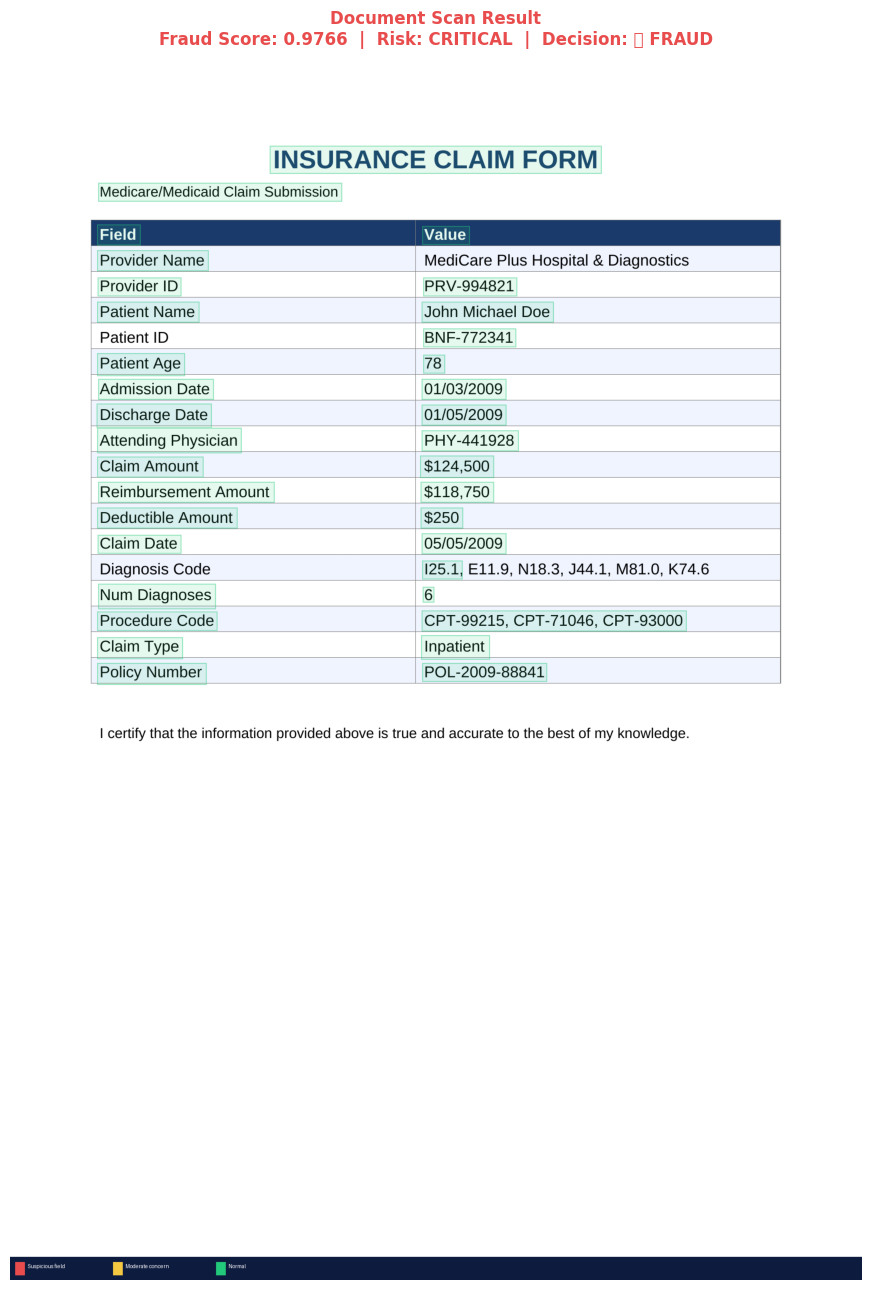


───────────────────────────────────────────────────────

███████████████████████████████████████████████████████
  TEST 2: NORMAL SCENARIO
███████████████████████████████████████████████████████

🔍 Scanning: /content/test_claim_NORMAL.pdf
───────────────────────────────────────────────────────
Step 1/5 — OCR extraction...
  PDF → converted page 1 of 1
  Running OCR on 1654×2339 image...
  ✅ Extracted 40 text regions
  ✅ Raw text length: 569 chars
Step 2/5 — Field parsing...
  Extracted 10 fields: ['claim_amount', 'reimbursement_amount', 'provider_name', 'admission_date', 'discharge_date', 'claim_date', 'diagnosis_code', 'patient_age', 'num_diagnoses', 'hospital_days']
Step 3/5 — Building model features...
Step 4/5 — Fraud prediction...
Step 5/5 — Highlighting document...
  💾 Highlighted image saved: /content/drive/MyDrive/insurance_fraud/scanned/scan_highlighted_20260328_053609.png

  SCAN RESULT
  Fraud Score : 0.4954
  Decision    : ✅ LEGITIMATE
  Risk Tier   : LOW
  Action      : A

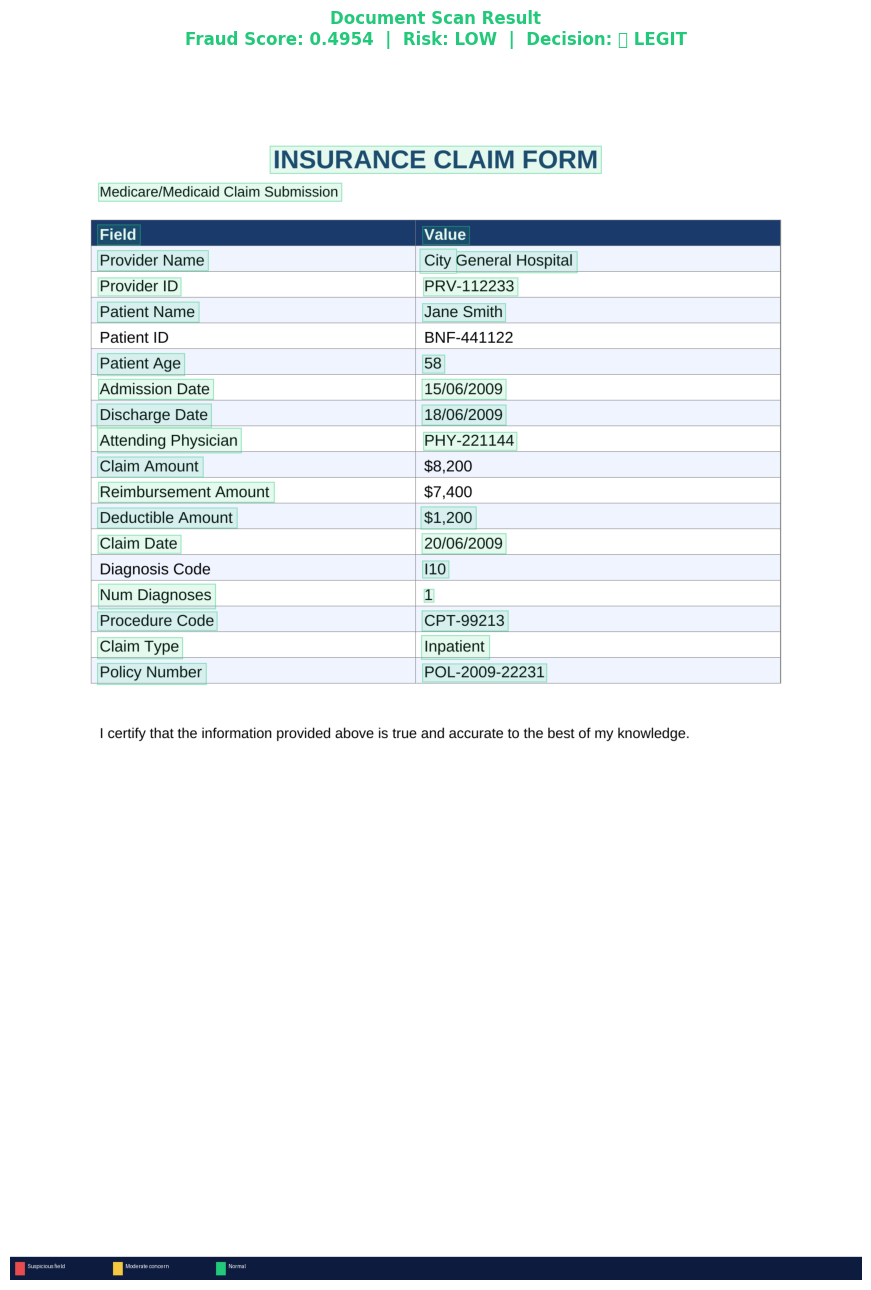

In [ ]:
# Scan HIGH FRAUD document
print('\n' + '█'*55)
print('  TEST 1: HIGH FRAUD SCENARIO')
print('█'*55)
results_fraud = scan_document(fraud_pdf, save_outputs=True)

# Display highlighted image
fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(results_fraud['annotated_image'])
ax.axis('off')
tier_colors = {'CRITICAL': RED, 'HIGH': '#FF8C42', 'MEDIUM': YELLOW, 'LOW': GREEN}
tier = results_fraud['risk_tier']
ax.set_title(
    f"Document Scan Result\n"
    f"Fraud Score: {results_fraud['fraud_score']:.4f}  |  "
    f"Risk: {tier}  |  "
    f"Decision: {'🚨 FRAUD' if results_fraud['fraud_pred'] else '✅ LEGIT'}",
    color=tier_colors.get(tier, WHITE), fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SCAN_DIR + 'scan_result_high_fraud.png', dpi=120,
            bbox_inches='tight', facecolor=NAVY)
plt.show()

print('\n' + '─'*55)

# Scan NORMAL document
print('\n' + '█'*55)
print('  TEST 2: NORMAL SCENARIO')
print('█'*55)
results_normal = scan_document(normal_pdf, save_outputs=True)

fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(results_normal['annotated_image'])
ax.axis('off')
tier = results_normal['risk_tier']
ax.set_title(
    f"Document Scan Result\n"
    f"Fraud Score: {results_normal['fraud_score']:.4f}  |  "
    f"Risk: {tier}  |  "
    f"Decision: {'🚨 FRAUD' if results_normal['fraud_pred'] else '✅ LEGIT'}",
    color=tier_colors.get(tier, WHITE), fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SCAN_DIR + 'scan_result_normal.png', dpi=120,
            bbox_inches='tight', facecolor=NAVY)
plt.show()

## Cell 13 — Gradio Interactive Demo UI
> Launch this for your project demonstration — faculty can upload any document and see live results

In [ ]:
def gradio_scan(file_obj):
    """
    Gradio wrapper for scan_document().
    Returns: annotated image, fraud score text, reasons text
    """
    if file_obj is None:
        return None, '⚠️ Please upload a file', ''

    try:
        results = scan_document(file_obj.name, save_outputs=False)

        score = results['fraud_score']
        tier  = results['risk_tier']
        pred  = results['fraud_pred']

        # Score summary text
        tier_emoji = {'CRITICAL':'🚨', 'HIGH':'⚠️', 'MEDIUM':'🟡', 'LOW':'✅'}
        score_text = (
            f"{tier_emoji.get(tier,'❓')} FRAUD SCORE: {score:.4f}\n"
            f"Risk Tier   : {tier}\n"
            f"Decision    : {'FRAUD — Do not process' if pred else 'LEGITIMATE'}\n"
            f"Action      : {results['action']}\n"
            f"Fields found: {len(results['extracted_fields'])}"
        )

        # Reasons text
        reasons_lines = ['TOP FRAUD SIGNALS:\n']
        for i, r in enumerate(results['reasons'][:5], 1):
            reasons_lines.append(f"{i}. {r['reason_text']}")
            reasons_lines.append(f"   SHAP contribution: +{r['shap']:.4f}\n")

        suspicious_fields = {
            k: v for k, v in results['field_scores'].items() if v['suspicious']
        }
        if suspicious_fields:
            reasons_lines.append('\nSUSPICIOUS FIELDS:')
            for field, info in suspicious_fields.items():
                reasons_lines.append(f"⚠️  {field}: {info['reason']}")

        reasons_text = '\n'.join(reasons_lines)
        return results['annotated_image'], score_text, reasons_text

    except Exception as e:
        return None, f'❌ Error: {str(e)}', 'Please check the file format (PDF/JPG/PNG)'


# Build Gradio interface
with gr.Blocks(
    title='Insurance Fraud Document Scanner',
    theme=gr.themes.Base(primary_hue='teal', neutral_hue='slate')
) as demo:

    gr.Markdown("""
    # 🛡️ Insurance Fraud Detection — Document Scanner
    **Upload a claim PDF or image → OCR extracts fields → AI scores each field → Fraud report generated**
    """)

    with gr.Row():
        with gr.Column(scale=1):
            file_input = gr.File(
                label='📎 Upload Claim Document (PDF / JPG / PNG)',
                file_types=['.pdf', '.jpg', '.jpeg', '.png']
            )
            scan_btn = gr.Button('🔍 Scan Document', variant='primary', size='lg')
            gr.Markdown('**Test files available:**')
            gr.Markdown('• `/content/test_claim_HIGH_FRAUD.pdf`')
            gr.Markdown('• `/content/test_claim_NORMAL.pdf`')

        with gr.Column(scale=2):
            annotated_img = gr.Image(label='📄 Highlighted Document'
                                     ' (Red = suspicious, Yellow = moderate, Green = normal)')

    with gr.Row():
        score_output   = gr.Textbox(label='🎯 Fraud Score & Decision', lines=6)
        reasons_output = gr.Textbox(label='📋 Fraud Reasons & Suspicious Fields', lines=10)

    scan_btn.click(
        fn=gradio_scan,
        inputs=[file_input],
        outputs=[annotated_img, score_output, reasons_output]
    )

    gr.Markdown("""
    ---
    **How it works:** EasyOCR extracts all text → Regex maps to claim fields →
    XGBoost (M4) scores the claim → SHAP explains which fields drove the score →
    Suspicious fields highlighted on the document image.
    """)

# Launch with public link (share=True for ngrok tunnel)
print('🚀 Launching Gradio demo...')
demo.launch(share=True, debug=False)

🚀 Launching Gradio demo...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://de9b8ebaf9304bb5b4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Cell 14 — M6 Summary

In [ ]:
print('='*65)
print('  M6 DOCUMENT SCANNER SUMMARY')
print('='*65)
print('  Components built:')
print('  ✅ EasyOCR engine         — extracts text + bounding boxes from PDF/image')
print('  ✅ Field parser           — 12 field types with regex patterns')
print('  ✅ Feature builder        — maps claim fields to 50+ model features')
print('  ✅ XGBoost scorer         — fraud probability from trained M4 model')
print('  ✅ SHAP explainer         — which fields drove the fraud score')
print('  ✅ Per-field suspicion    — individual score + reason for each field')
print('  ✅ Document highlighter   — red/yellow/green overlay on original image')
print('  ✅ Gradio demo UI         — live upload → scan → report in browser')
print()
print('  Test results:')
print(f'  HIGH FRAUD doc score : {results_fraud["fraud_score"]:.4f}  ({results_fraud["risk_tier"]})')
print(f'  NORMAL doc score     : {results_normal["fraud_score"]:.4f}  ({results_normal["risk_tier"]})')
print()
print('  Files saved to:')
print(f'  {SCAN_DIR}')
print()
print('  📌 Next: M7_Deployment.ipynb — FastAPI backend + ngrok public URL')
print('='*65)

  M6 DOCUMENT SCANNER SUMMARY
  Components built:
  ✅ EasyOCR engine         — extracts text + bounding boxes from PDF/image
  ✅ Field parser           — 12 field types with regex patterns
  ✅ Feature builder        — maps claim fields to 50+ model features
  ✅ XGBoost scorer         — fraud probability from trained M4 model
  ✅ SHAP explainer         — which fields drove the fraud score
  ✅ Per-field suspicion    — individual score + reason for each field
  ✅ Document highlighter   — red/yellow/green overlay on original image
  ✅ Gradio demo UI         — live upload → scan → report in browser

  Test results:
  HIGH FRAUD doc score : 0.9766  (CRITICAL)
  NORMAL doc score     : 0.4954  (LOW)

  Files saved to:
  /content/drive/MyDrive/insurance_fraud/scanned/

  📌 Next: M7_Deployment.ipynb — FastAPI backend + ngrok public URL
